<h3><b>Introduction to Data Analytics - Exercise set 4, advanced exercise 1</b></h3>

<h4><b>Employee satisfaction dataset</b></h4>
<h3 style="color: red;">NOTE! This notebook requires that your Python environment has <i>openpyxl</i>-module installed (excel-file support).</h3>
<h4>To install: <b style="color: red;">pip install openpyxl</b></h4>
<h3>After this, restart your Jupyter kernel (Restart -button in top of notebook).</h3>
<img src="http://srv.plab.fi/~tuomasv/data_analytics_2023_images/exercise_set_4/office.png" />

<hr /><h1>!!!!! IMPORTANT !!!!!</h1> 

<h2>Do not use generative AI in this exercise!</h2>
<b>Remember:</b> in working life, we are not allowed to freely share our data with just any generative AI, since the data is often sensitive and owned by a client. 

Generative AIs would use the data to train themselves in the future, which is a violation of regulations.
The point of this exercise set is to <b>MANUALLY</b> inspect the plots in the examples and learn how to see trends and features in the data.
 
See also the materials discussing the usage of AI in this course!
<hr />

<b>Tip:</b> You can just click "Run All" to see the results of this notebook. Some of these exercises have some heavy plots that can take even 1 minute to produce.

<b>Remember:</b> not every dataset has interesting correlations and/or features (too much randomness or variance usually, or not enough data, or data is just self-explanatory). Also, not each correlation implies there's a causation. Finally, not every plot is useful, that's why it's important to try multiple plots in order to "see under the hood". Typically pair plots, joint plots, regression plots, heatmaps and box plots are most useful, but there are some exceptions too.

<h3><b>Quick summary of data:</b></h3>

<p>This dataset contains employee data of an unknown company, containing multiple variables. These include the level of satisfaction in their job (0-100%), how many years since last evaluation, number of projects the employee is currently working on, average works hours in last 3 months, time spend while traveling to work, whether employee has been in a work accident, if the employee has left the company, whether the employee has had a promotion in last 5 years and the department they work in.</p>

<p>Original data: <a href="https://www.kaggle.com/datasets/kmldas/hr-employee-data-descriptive-analytics">https://www.kaggle.com/datasets/kmldas/hr-employee-data-descriptive-analytics</a></p>

<h3><b>Questions for this exercise:</b></h3>
<b>Answer the questions either as code comments or as markdown. Use separate cells to write your answers.</b><br/><br/>
<li>Which columns affect most the satisfaction of the employee in the company? What are the most obvious factors?</li>
<li>What features happy employees typically have? How about unhappy employees?</li>
<li>Are there any notable differences between salary levels or Department?</li>
<li>According to correlation matrix, there's only one column that correlates with satisfaction somewhat. How much information about the connections in the data is lost if we only inspect the correlation matrix?</li>

<b>Optional questions/tasks for extra points:</b>
<li>Based on this dataset, what would be the easiest way to make employees happier?</li>
<li>Any other interesting correlations or phenomena in this dataset?</li>
<li>Do the correlations and/or other connections change considerably, if salary levels and/or departments are inspected separately? (this is an extra difficult task: the idea is to filter a new dataframe with a single salary level or a department, and try out different plots)</li>
<li>Any other ideas about this dataset? Any ways to expand or improve the dataset and the analysis?</li>


<hr />

# Basic Questions

<div style="border: 3px dashed white; padding: 10px;"> 
<h3>Question 1</h3>

Which columns affect most the satisfaction of the employee in the company? What are the most obvious factors?

<h3>Answer</h3>



</div>

<div style="border: 3px dashed white; padding: 10px;"> 
<h3>Question 2</h3>

What features happy employees typically have? How about unhappy employees?

<h3>Answer</h3>



</div>

<div style="border: 3px dashed white; padding: 10px;"> 
<h3>Question 3</h3>

Are there any notable differences between salary levels or Department?

<h3>Answer</h3>



</div>

<div style="border: 3px dashed white; padding: 10px;"> 
<h3>Question 4</h3>

According to correlation matrix, there's only one column that correlates with satisfaction somewhat. How much information about the connections in the data is lost if we only inspect the correlation matrix?

<h3>Answer</h3>



</div>

---

# Extra Questions

<div style="border: 3px dashed white; padding: 10px;"> 
<h3>Question 1</h3>

Based on this dataset, what would be the easiest way to make employees happier?

<h3>Answer</h3>



</div>

<div style="border: 3px dashed white; padding: 10px;"> 
<h3>Question 2</h3>

Any other interesting correlations or phenomena in this dataset?

<h3>Answer</h3>



</div>

<div style="border: 3px dashed white; padding: 10px;"> 
<h3>Question 3</h3>

Do the correlations and/or other connections change considerably, if salary levels and/or departments are inspected separately? (this is an extra difficult task: the idea is to filter a new dataframe with a single salary level or a department, and try out different plots)

<h3>Answer</h3>



</div>

<div style="border: 3px dashed white; padding: 10px;"> 
<h3>Question 4</h3>

Any other ideas about this dataset? Any ways to expand or improve the dataset and the analysis?

<h3>Answer</h3>



</div>

<hr />

<h4><b>Imports and load the original dataset</b></h4>

In [1]:
# import the common data analytics modules
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

<h4><b>Helper functions for data clean-up</b></h4>

In [2]:
# helper function to have a solid category for certain ranges
# this makes it helper to use regression and box plots with hue
def create_last_evaluation_category(row):
    evaluation = row['last_evaluation']

    if evaluation < 0.5:
        return "Recently"
    elif 0.5 <= evaluation <= 0.75:
        return "Some time ago"
    elif evaluation > 0.75:
        return "Long time ago"

<h4><b>Data processing</b></h4>

In [3]:
# load dataset and drop the employee id -column (can't be used in any analytics)
# and yes, pandas can also read excel-files, but they usually have extra empty lines etc.
# that need more cleaning up before attempting to process the data with pandas.
# this dataset, however, seems to be very clean, regardless being an excel-file
df = pd.read_excel('HR_Employee_Data.xlsx')
df = df.drop("Emp_Id", axis=1)

# get correlations
correlations = df.corr(numeric_only=True)

# this dataset is a bit too big to use certain plots, like pair plot
# taking a smaller sample might be a good idea

# set a random seed (so you get every time the same sample)
# and get a sample of 3000 employees in order to more easily create readable plots
np.random.seed(313)
df_sample = df.sample(3000)

<h4><b>seaborn plots - pair plots</b></h4>

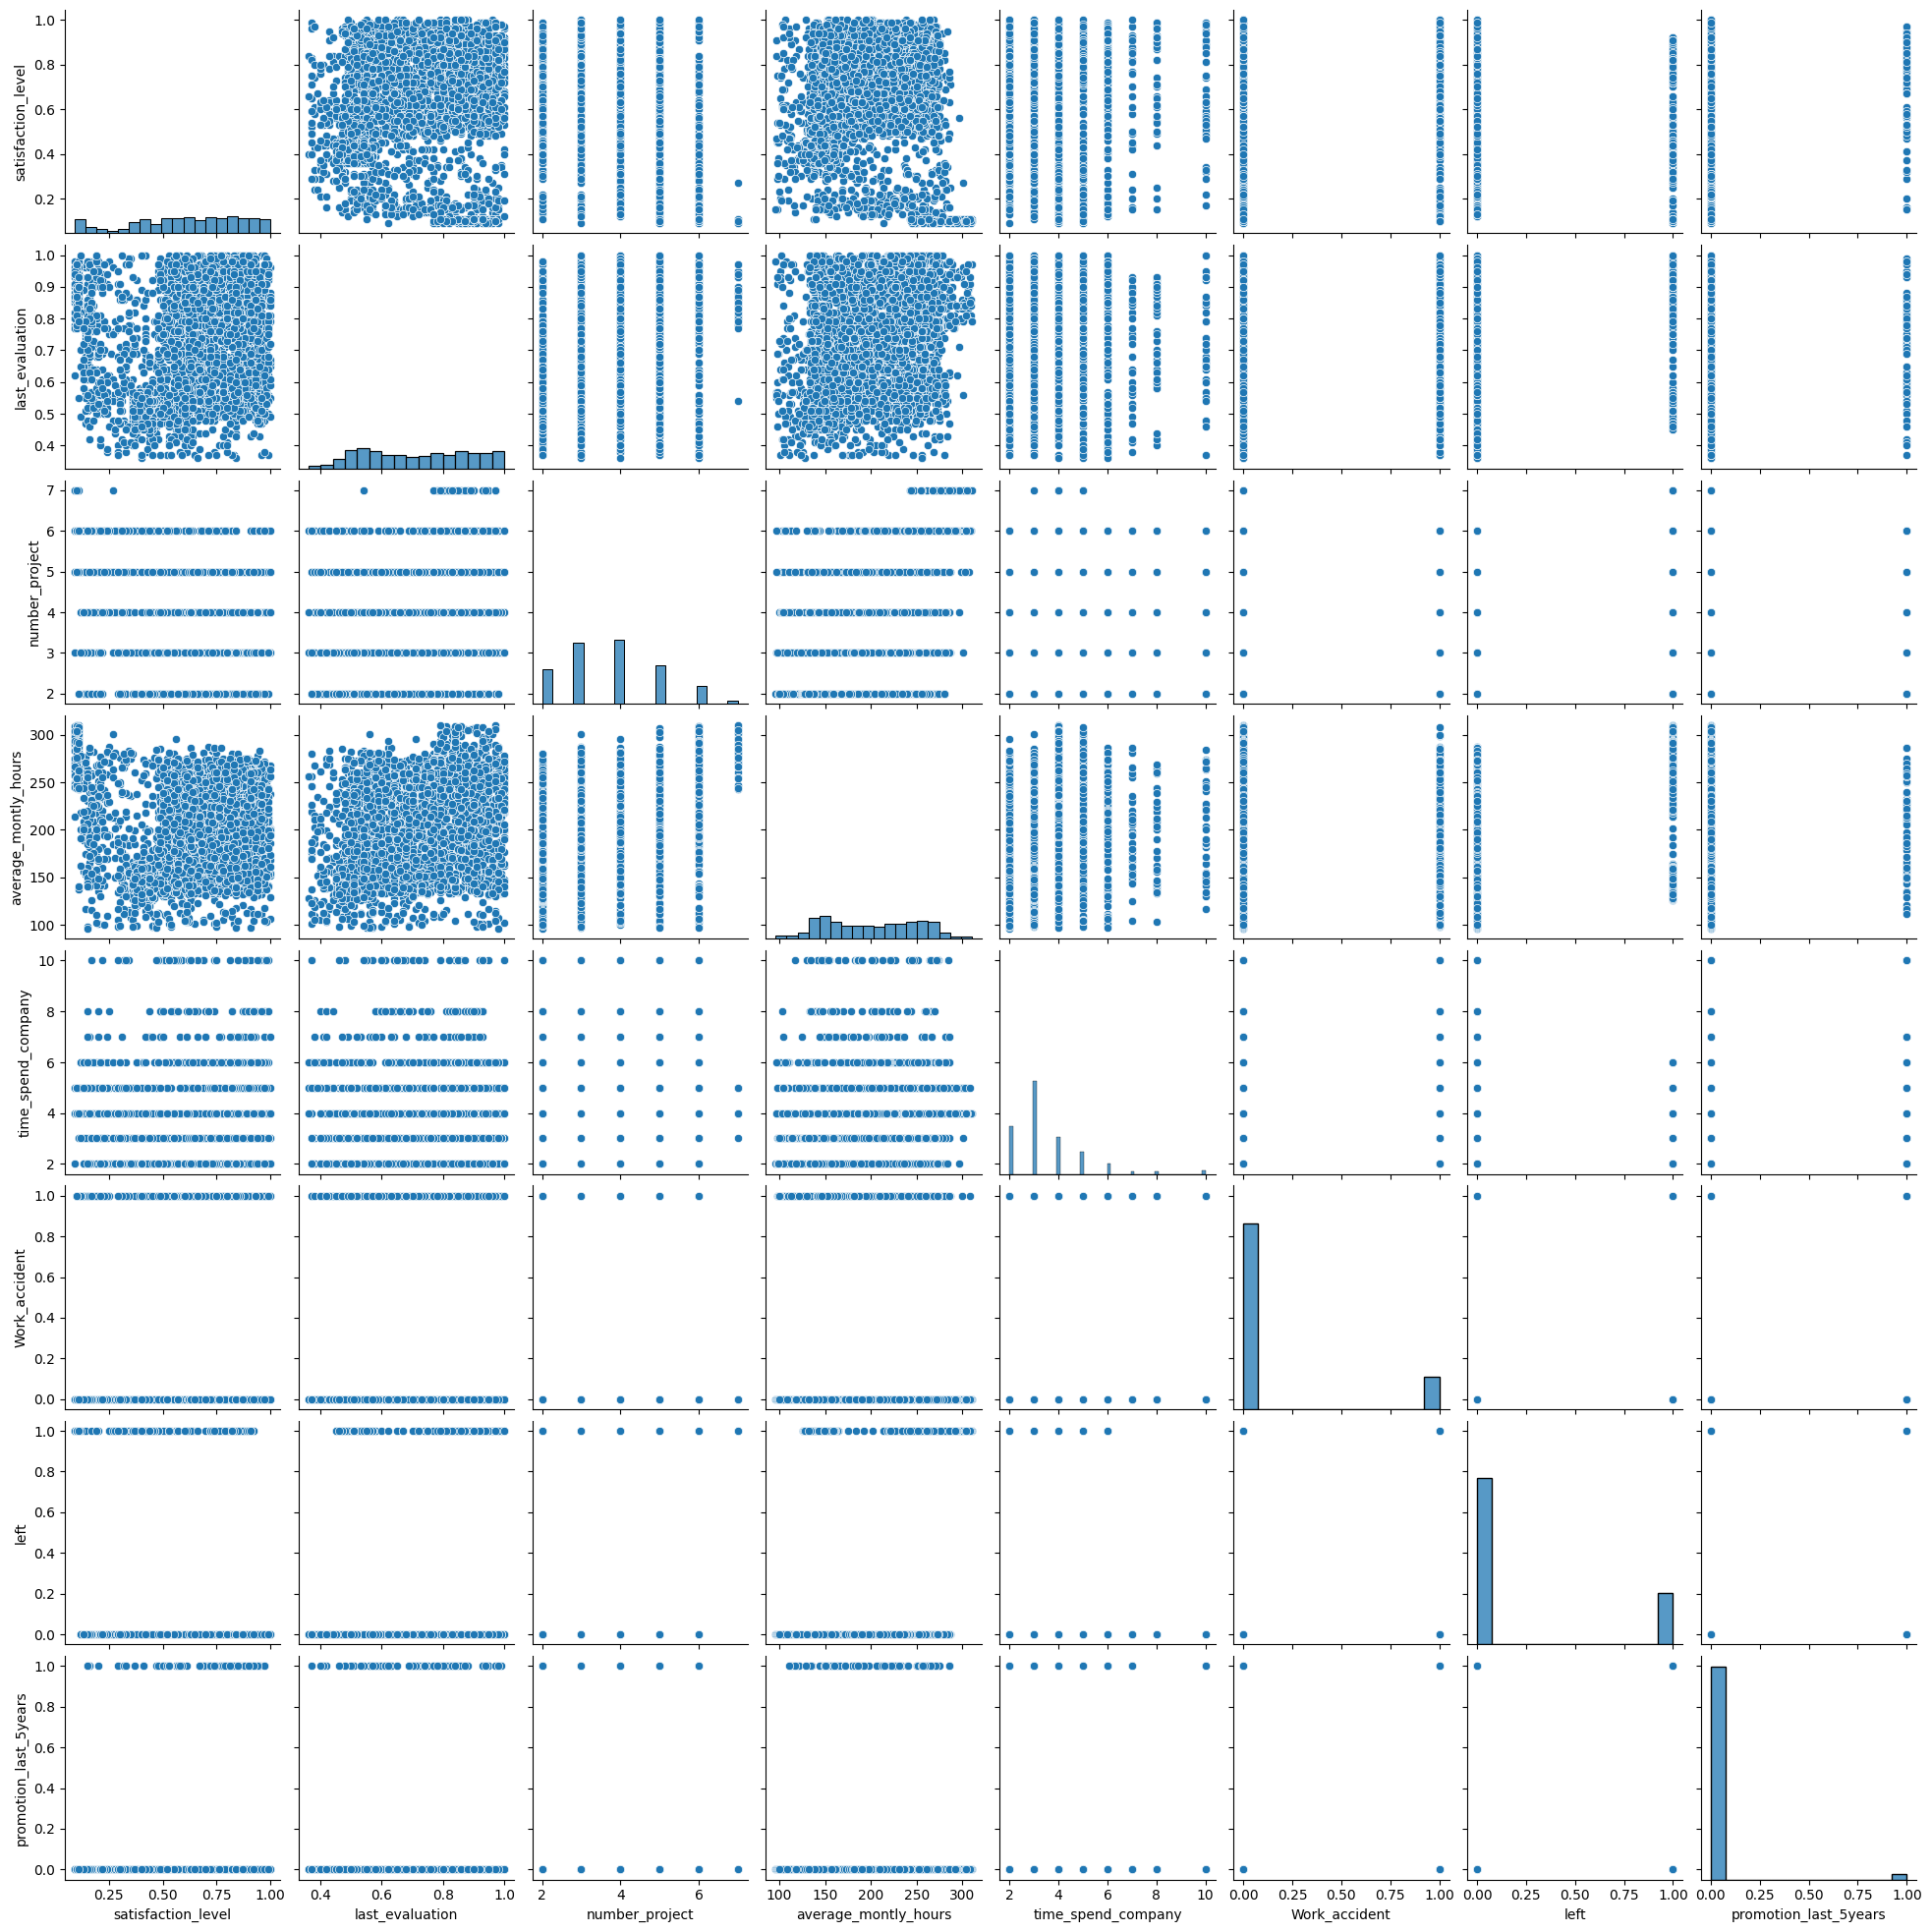

In [4]:
# basic pair plot
sns.pairplot(df_sample)

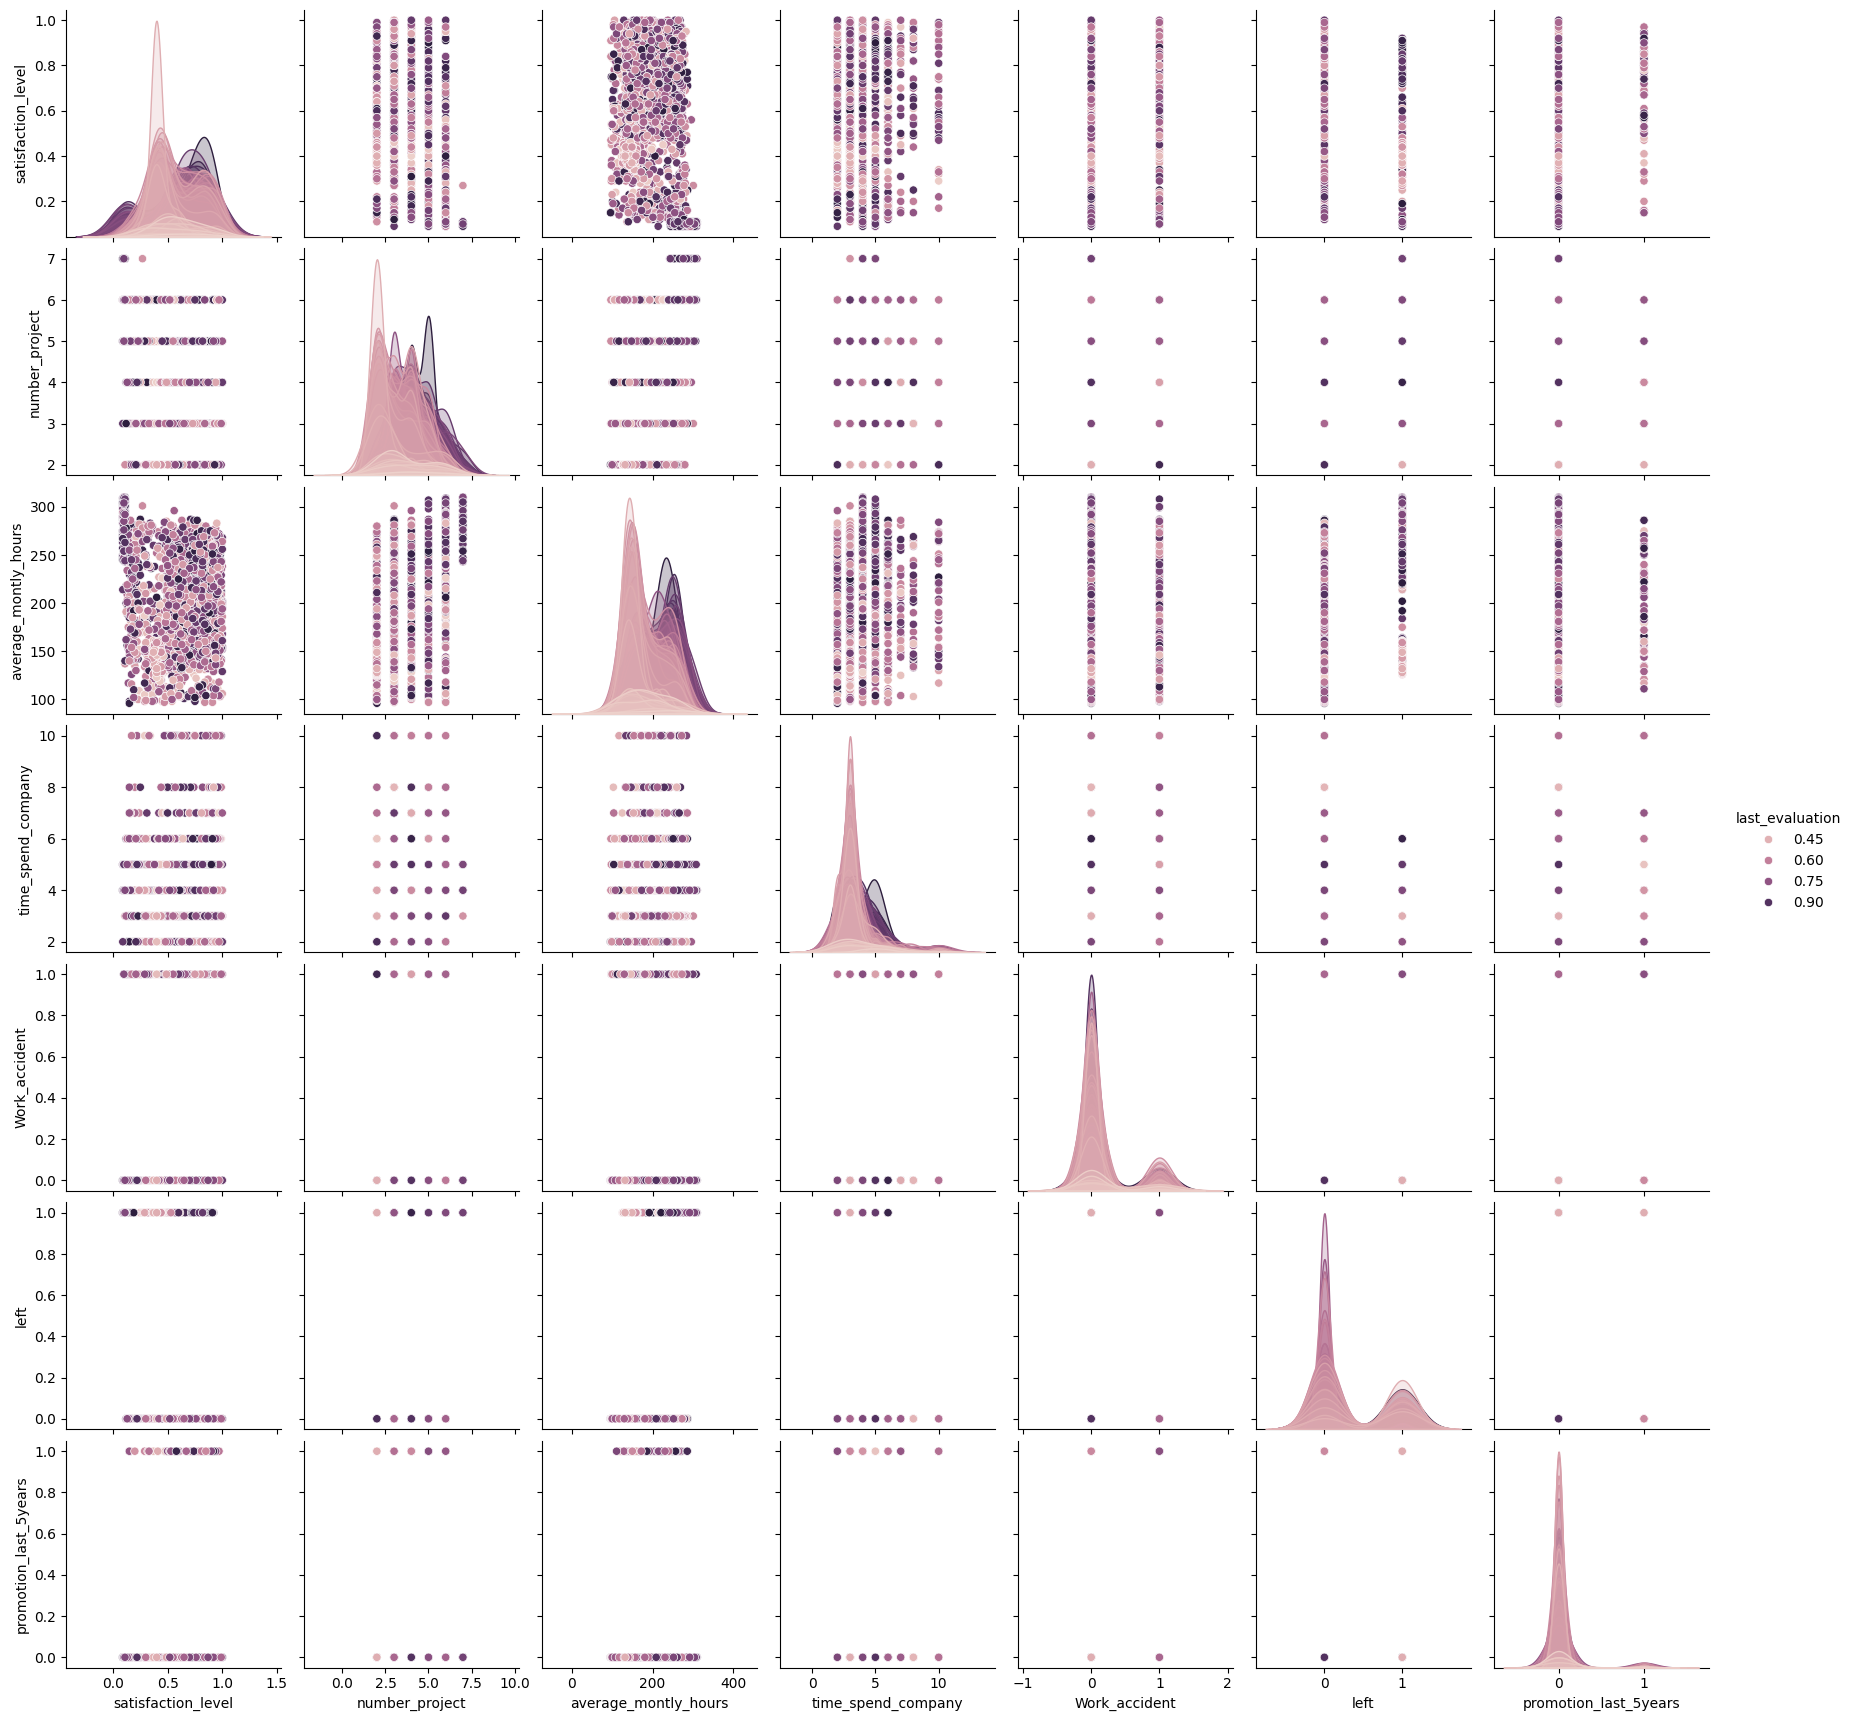

In [5]:
# basic pair plot, hue on last evaluation (continuous variable between 0 and 1)
sns.pairplot(df_sample, hue="last_evaluation")

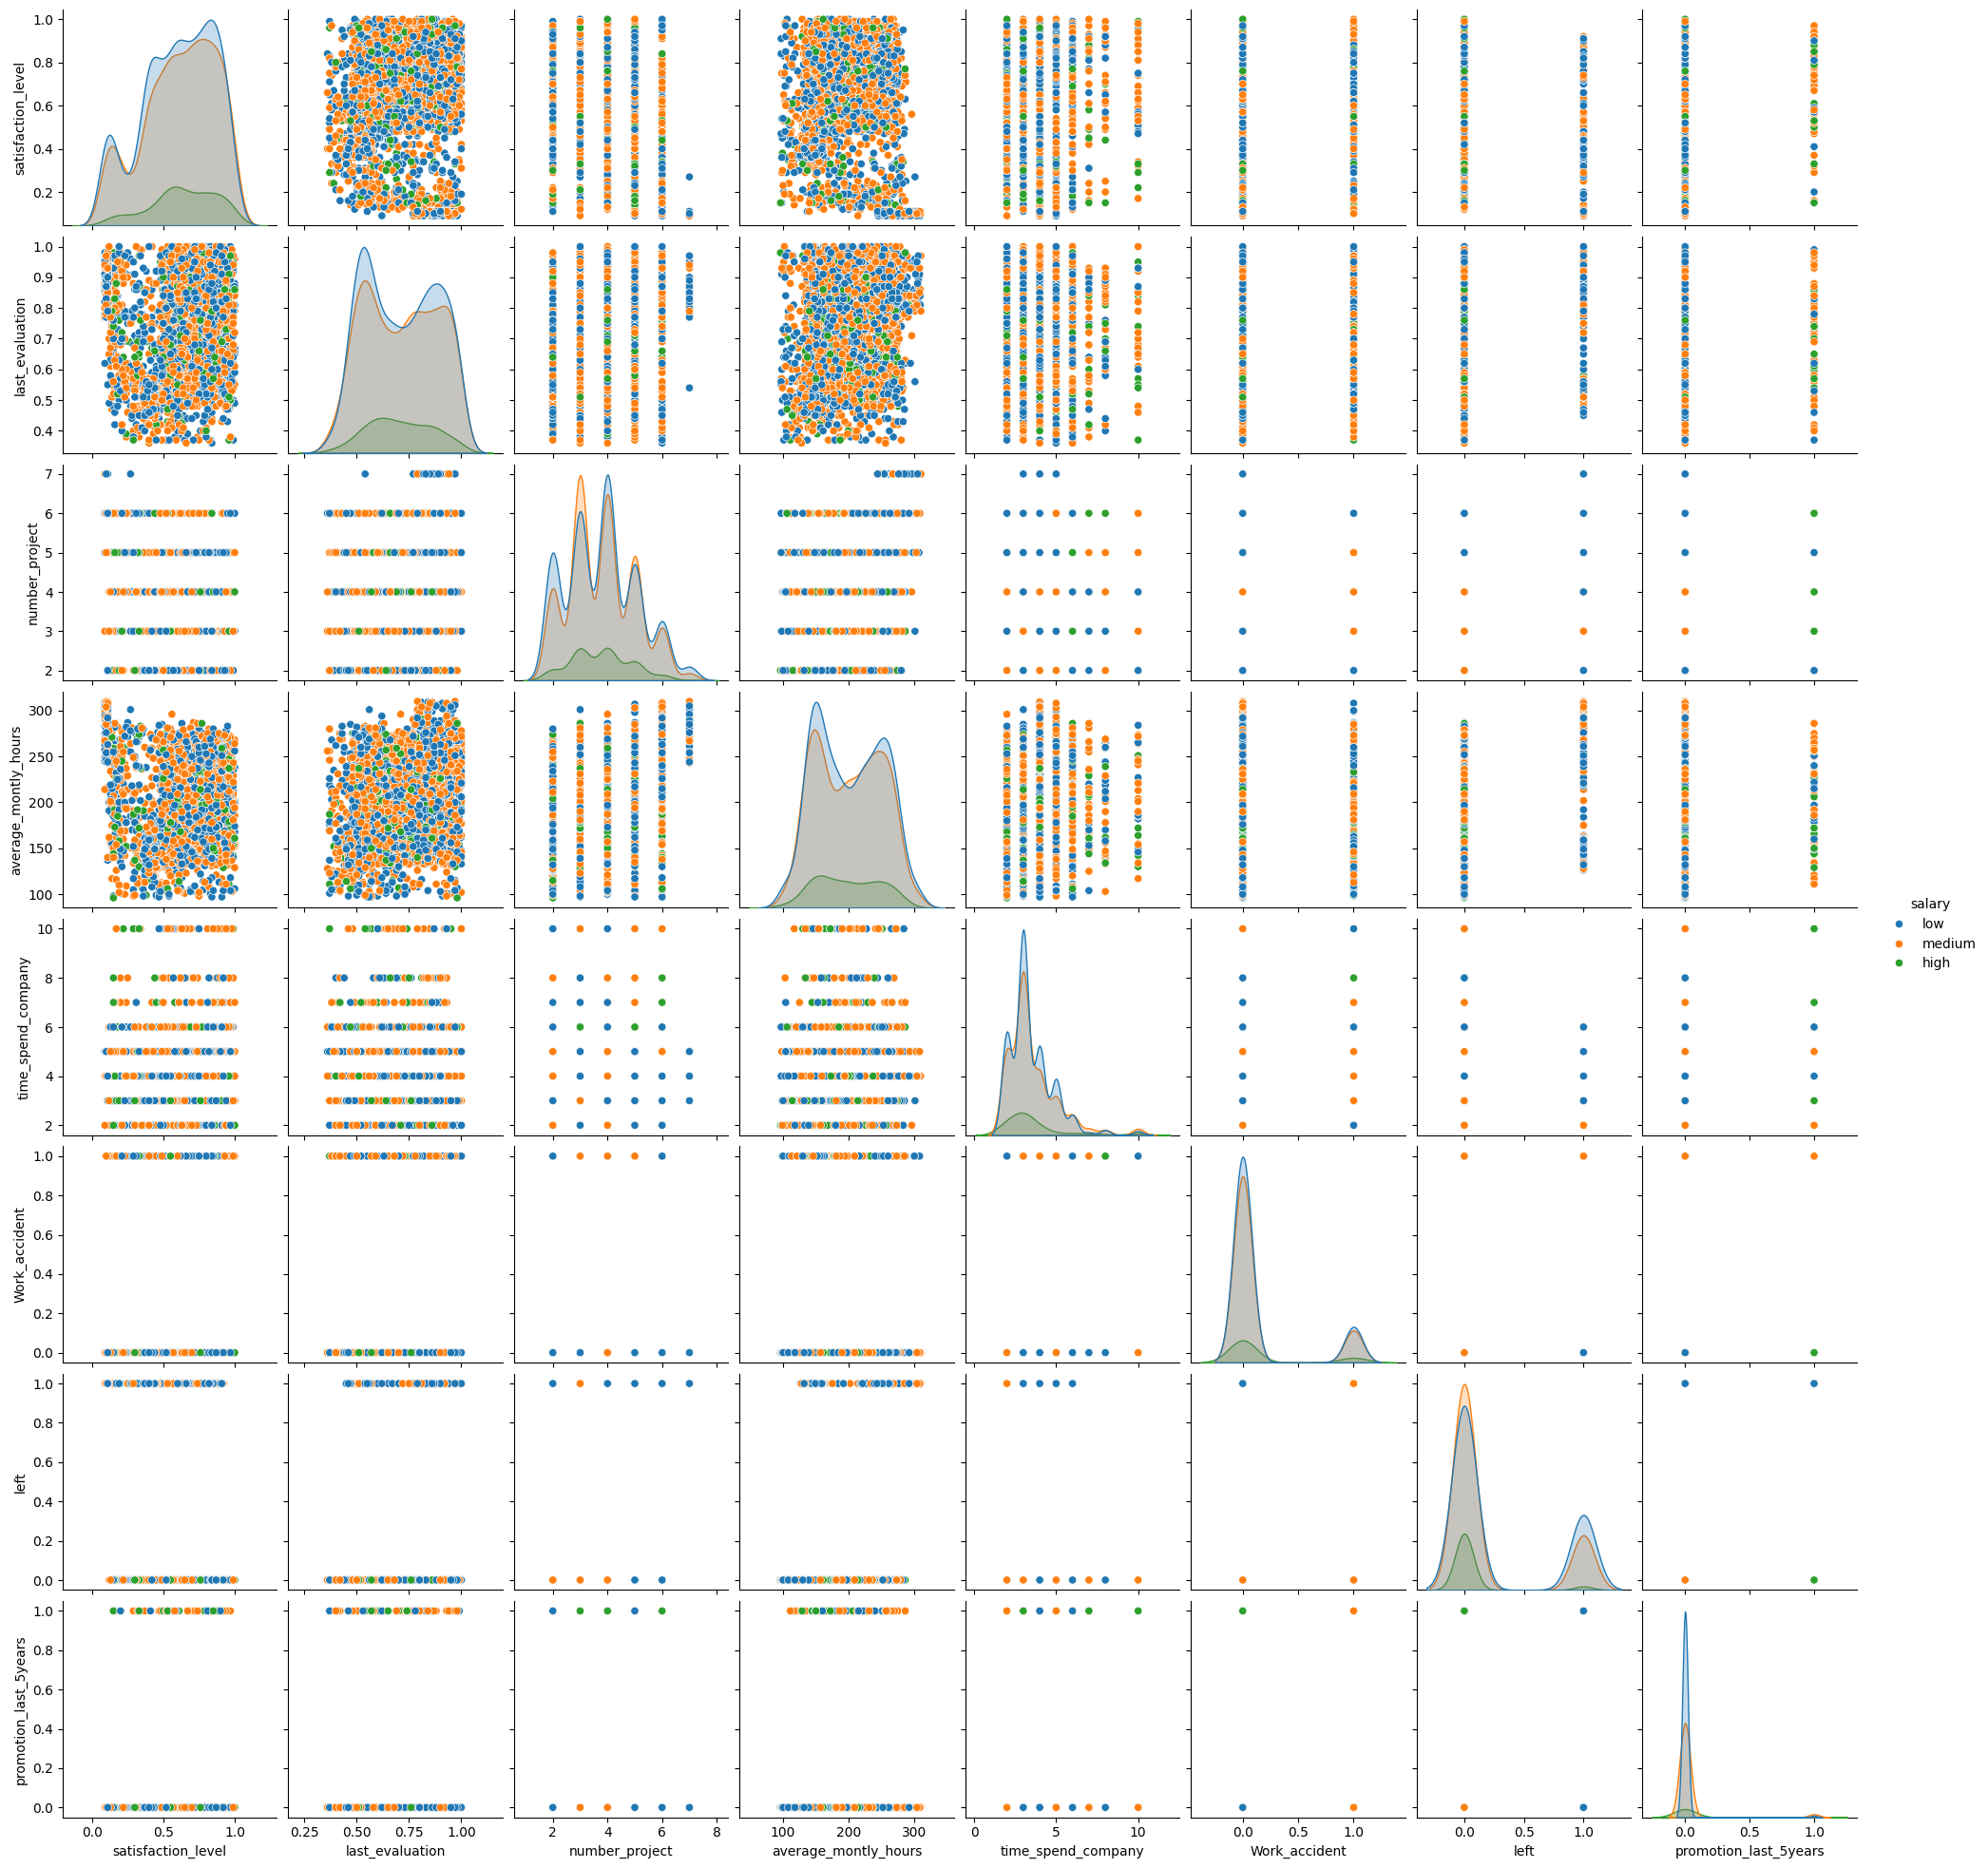

In [6]:
# basic pair plot, hue on salary
sns.pairplot(df_sample, hue="salary")

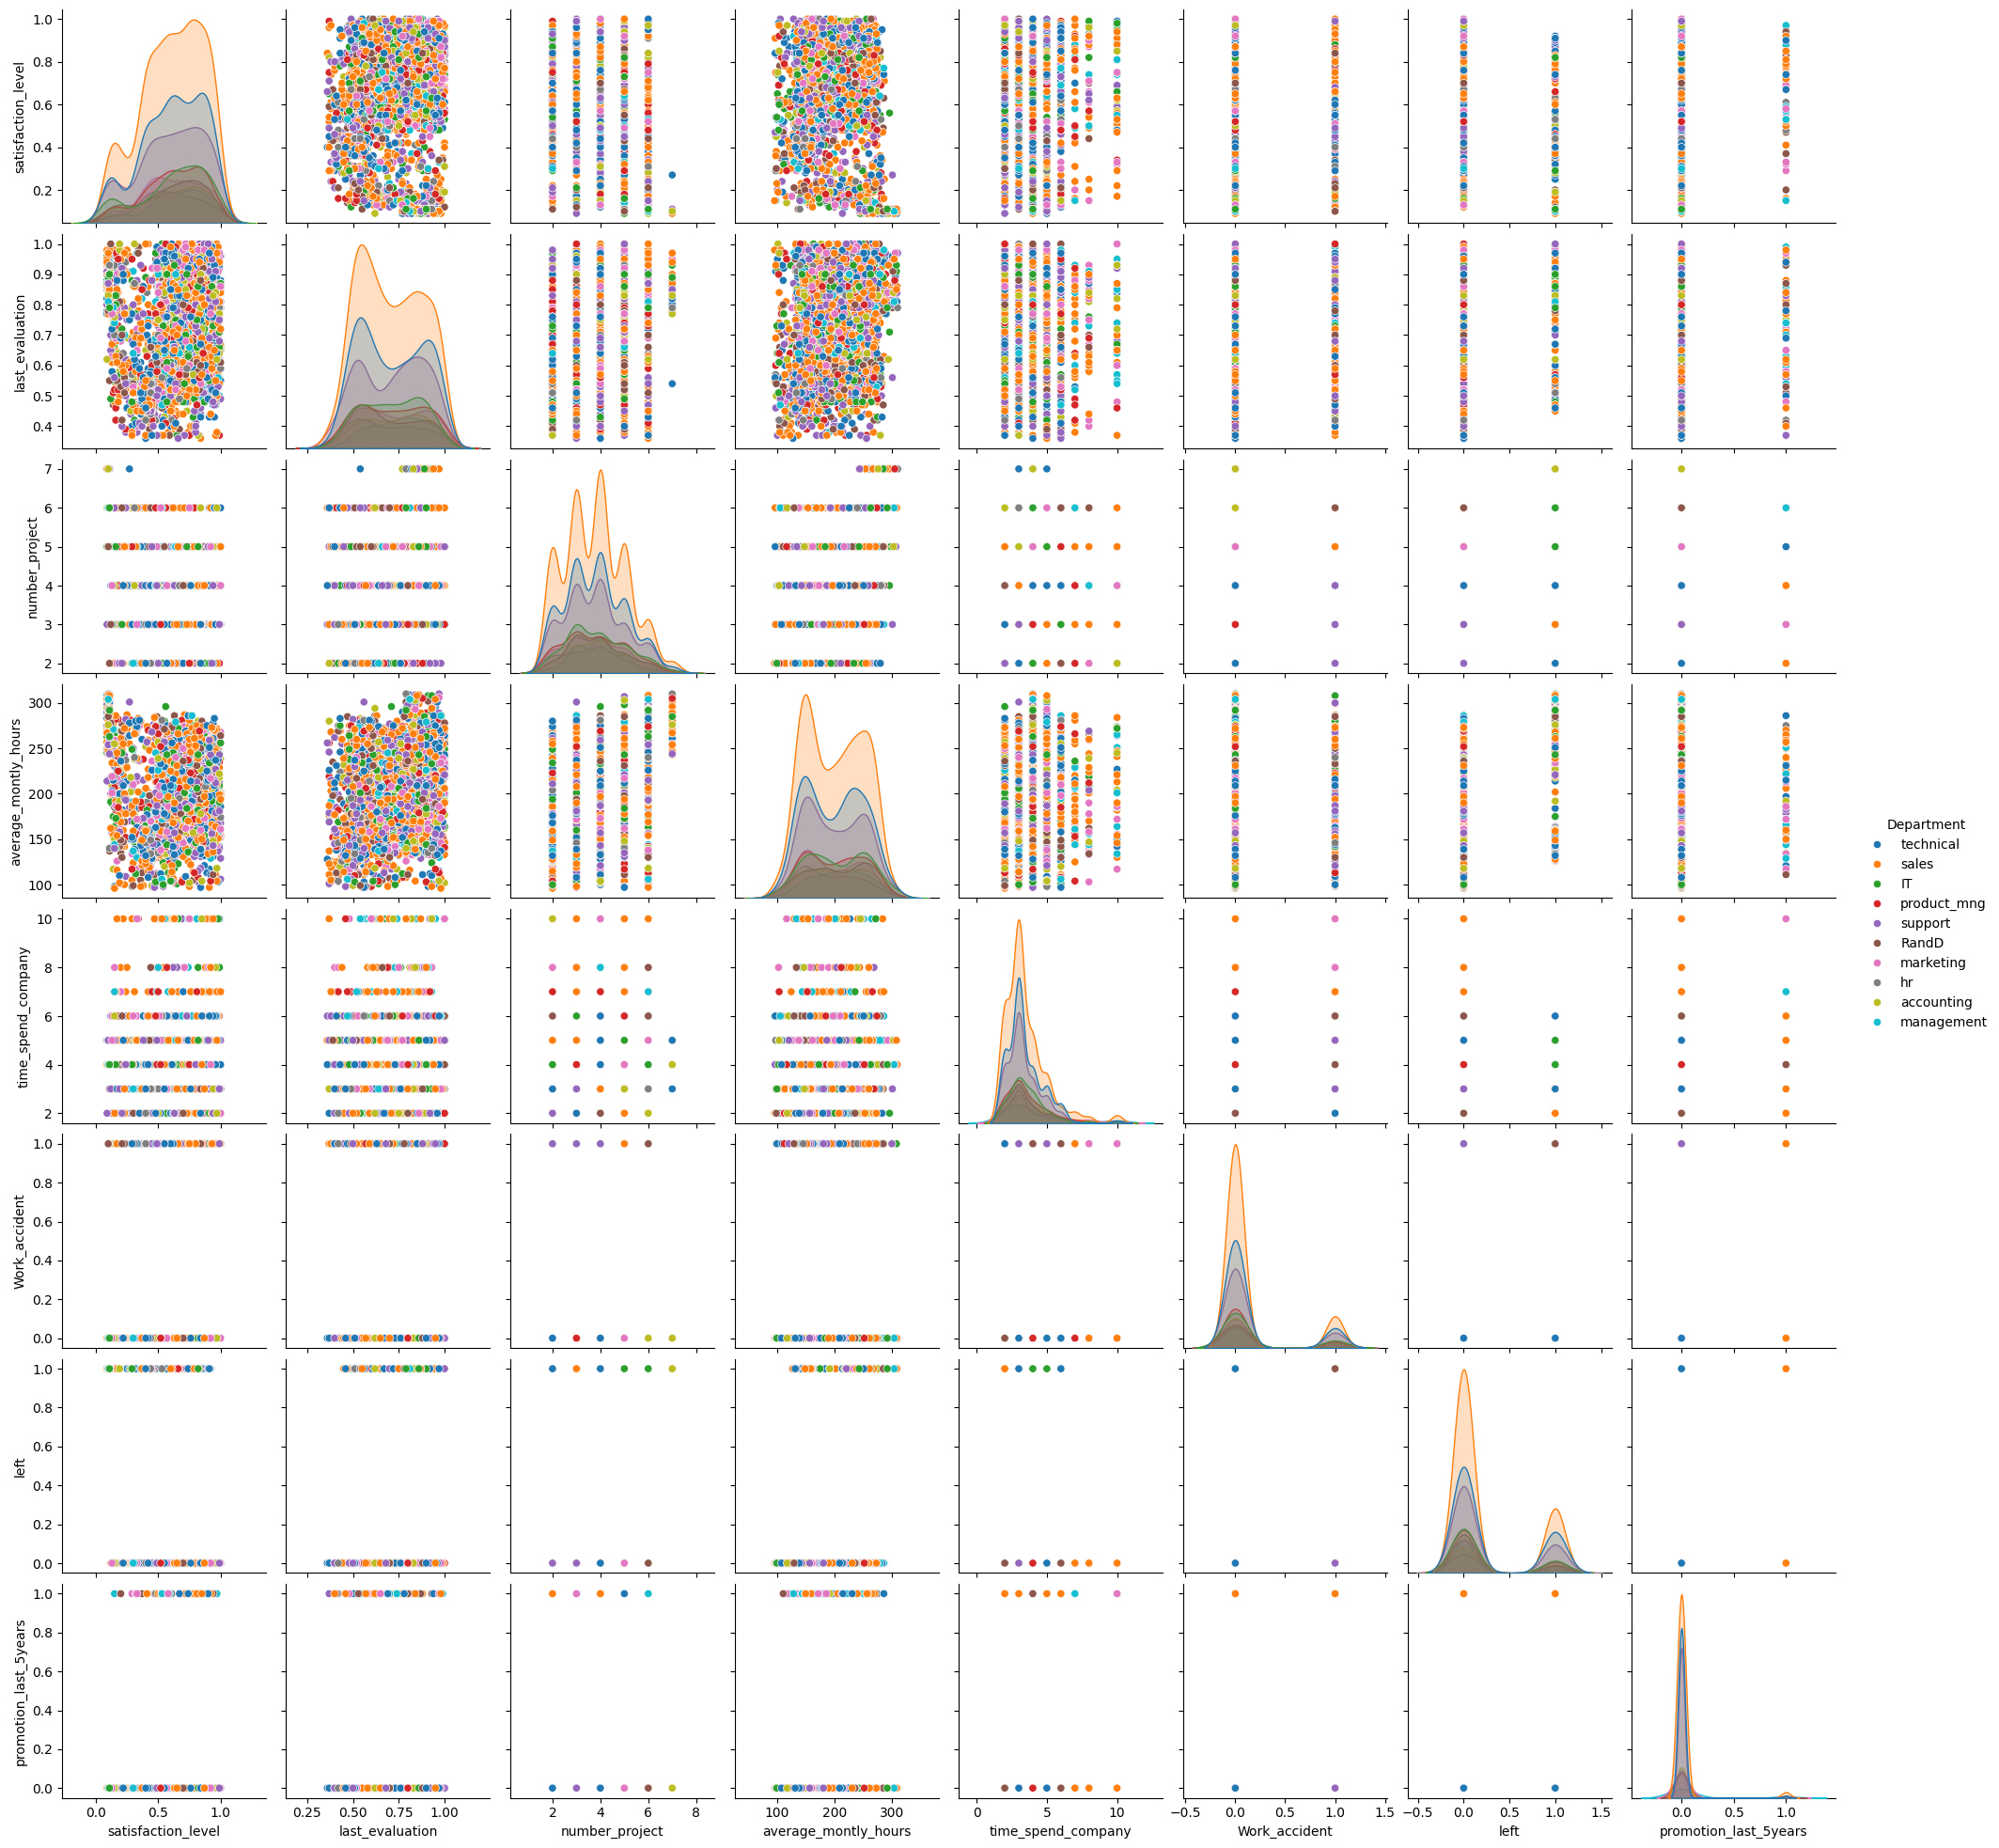

In [7]:
# basic pair plot, hue on department the employees work in
sns.pairplot(df_sample, hue='Department')

<h4><b>seaborn plots - regression plots</b></h4>

In [8]:
# create a new field for an estimated category of evaluation (more useful with regression plots and box plots)
df_sample['last_evaluation_category'] = df_sample.apply(create_last_evaluation_category, axis=1)

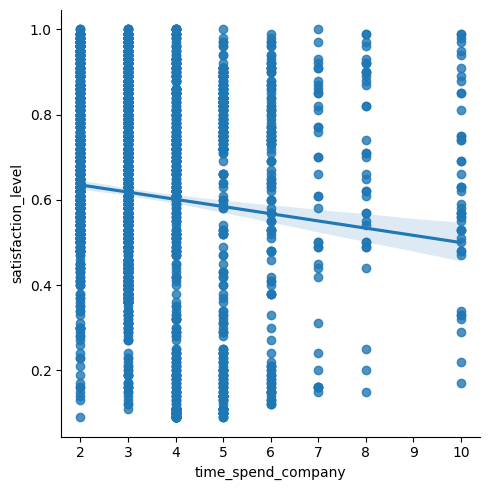

In [9]:
# regression plot, satisfaction vs amount of time spent while traveling to work
sns.lmplot(x='time_spend_company', y='satisfaction_level', data=df_sample)

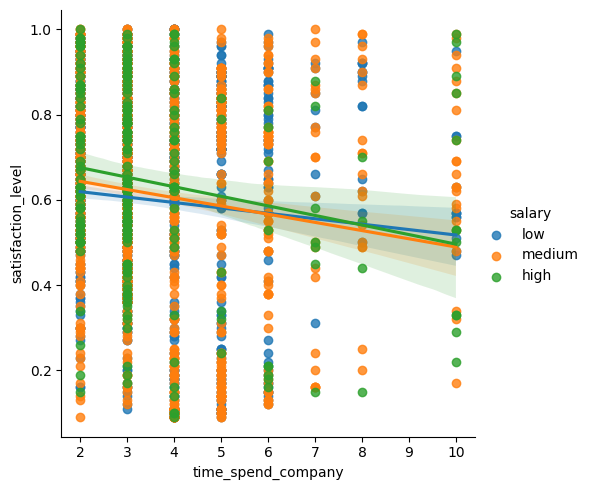

In [10]:
# regression plot, satisfaction vs amount of time spent while traveling to work, hue on salary
sns.lmplot(x='time_spend_company', y='satisfaction_level', data=df_sample, hue="salary")

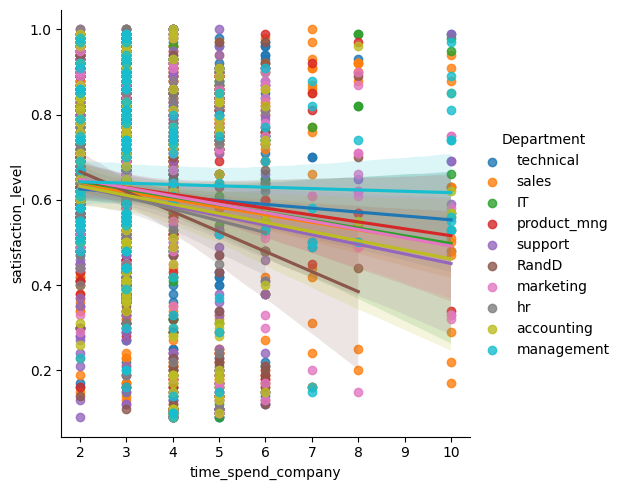

In [11]:
# regression plot, satisfaction vs amount of time spent while traveling to work, hue on department
sns.lmplot(x='time_spend_company', y='satisfaction_level', data=df_sample, hue="Department")

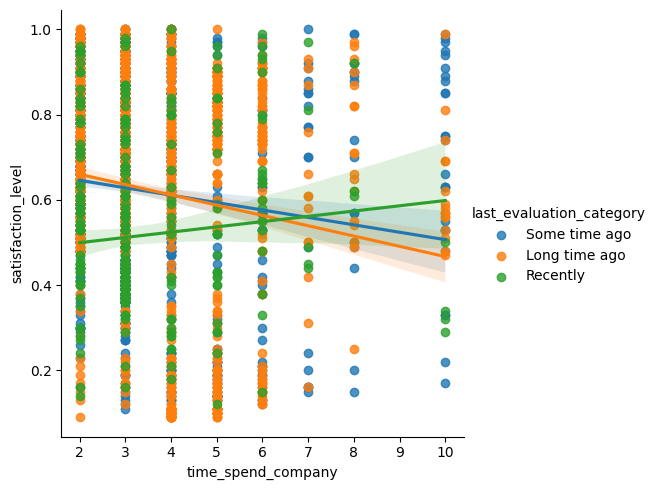

In [12]:
# regression plot, satisfaction vs amount of time spent while traveling to work, hue on last evaluation category
sns.lmplot(x='time_spend_company', y='satisfaction_level', data=df_sample, hue="last_evaluation_category")

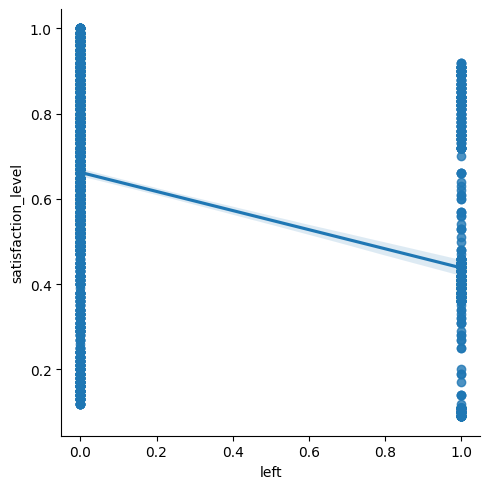

In [13]:
# regression plot, satisfaction vs if employee has left the company
sns.lmplot(x='left', y='satisfaction_level', data=df_sample)

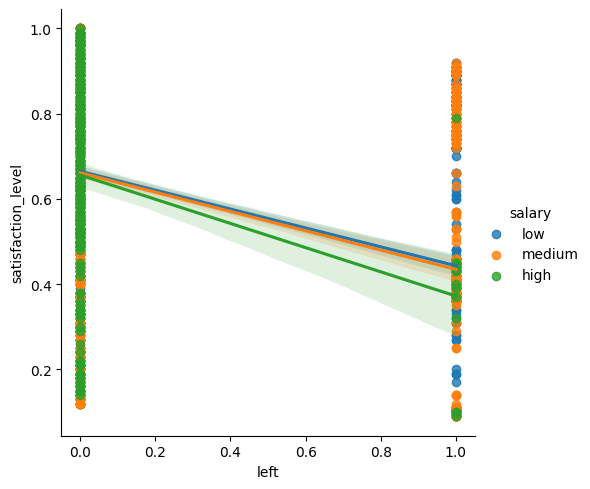

In [14]:
# regression plot, satisfaction vs if employee has left the company, hue on salary
sns.lmplot(x='left', y='satisfaction_level', data=df_sample, hue="salary")

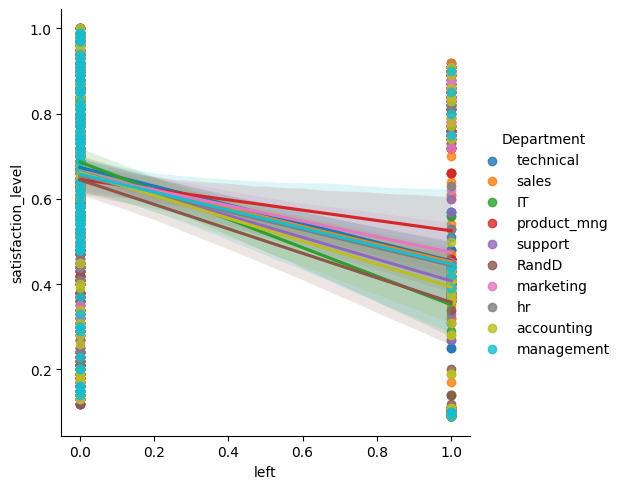

In [15]:
# regression plot, satisfaction vs if employee has left the company, hue on department
sns.lmplot(x='left', y='satisfaction_level', data=df_sample, hue="Department")

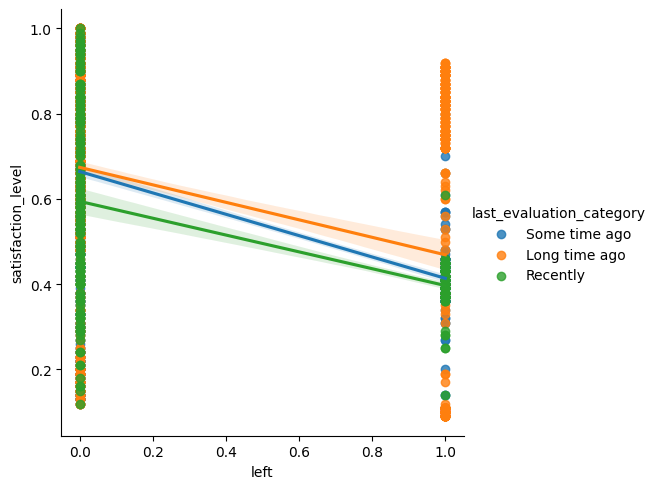

In [16]:
# regression plot, satisfaction vs if employee has left the company, hue on last evaluation category
sns.lmplot(x='left', y='satisfaction_level', data=df_sample, hue="last_evaluation_category")

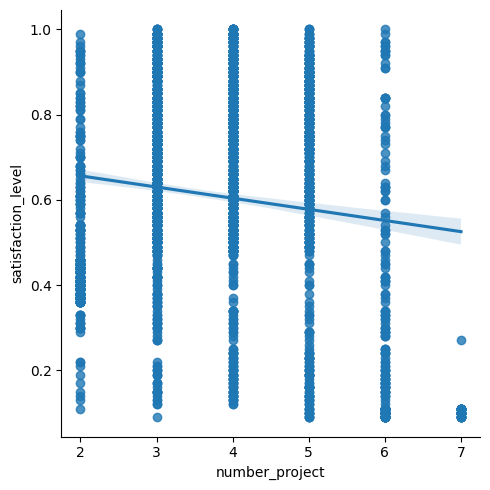

In [17]:
# regression plot, satisfaction vs number of project employee is working on currently
sns.lmplot(x='number_project', y='satisfaction_level', data=df_sample)

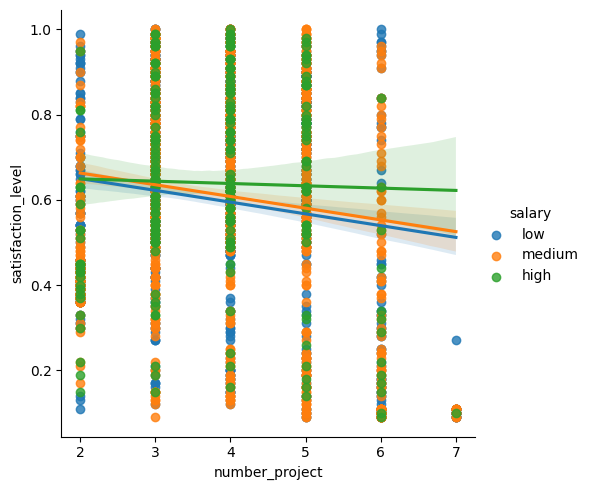

In [18]:
# regression plot, satisfaction vs number of project employee is working on currently, hue on salary
sns.lmplot(x='number_project', y='satisfaction_level', data=df_sample, hue="salary")

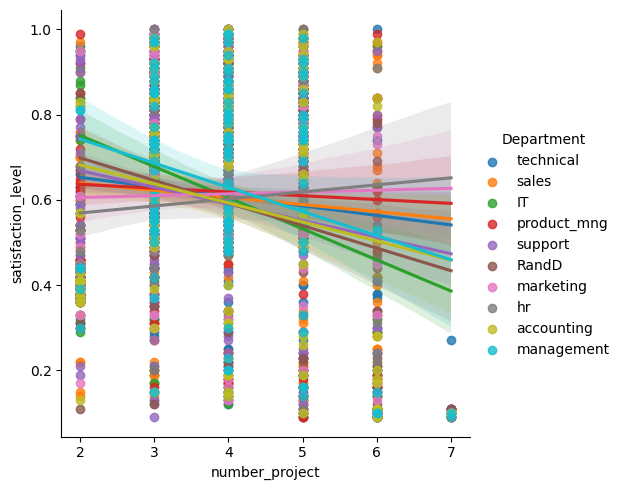

In [19]:
# regression plot, satisfaction vs number of project employee is working on currently, hue on department
sns.lmplot(x='number_project', y='satisfaction_level', data=df_sample, hue="Department")

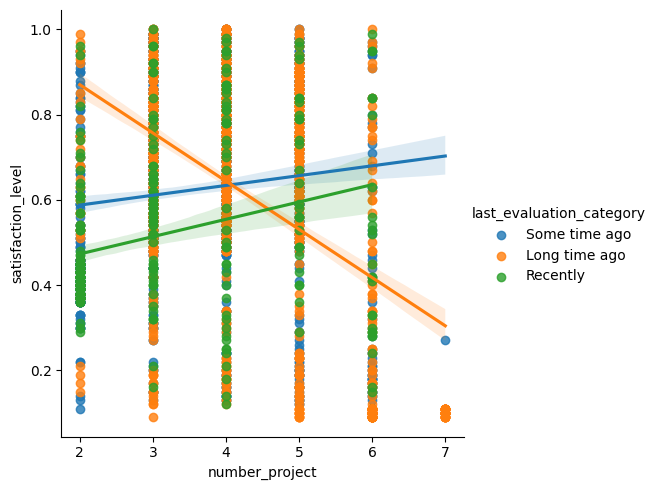

In [20]:
# regression plot, satisfaction vs number of project employee is working on currently, hue on last evaluation category
sns.lmplot(x='number_project', y='satisfaction_level', data=df_sample, hue='last_evaluation_category')

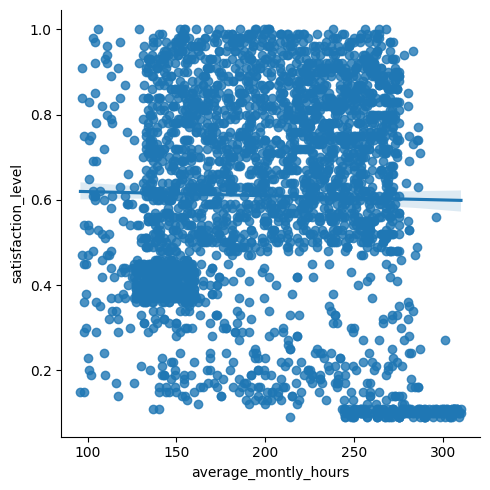

In [21]:
# regression plot, satisfaction vs average monthly hours is working on currently
sns.lmplot(x='average_montly_hours', y='satisfaction_level', data=df_sample)

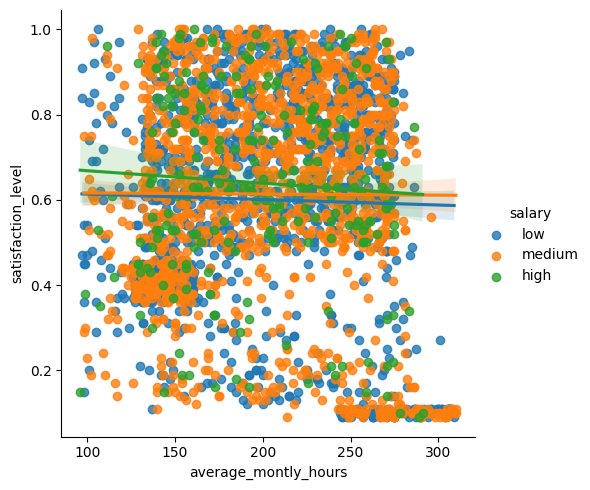

In [22]:
# regression plot, satisfaction vs average monthly hours is working on currently, hue on salary
sns.lmplot(x='average_montly_hours', y='satisfaction_level', data=df_sample, hue='salary')

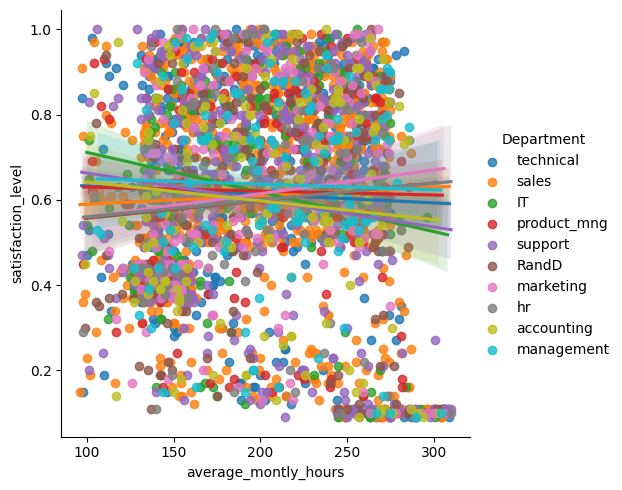

In [23]:
# regression plot, satisfaction vs average monthly hours is working on currently, hue on department
sns.lmplot(x='average_montly_hours', y='satisfaction_level', data=df_sample, hue='Department')

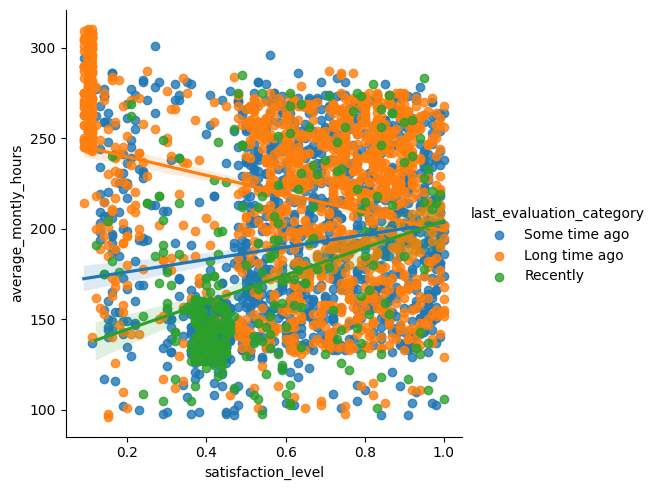

In [24]:
# regression plot, satisfaction vs average monthly hours is working on currently, hue on last evaluation category
sns.lmplot(x='satisfaction_level', y='average_montly_hours', data=df_sample, hue='last_evaluation_category')

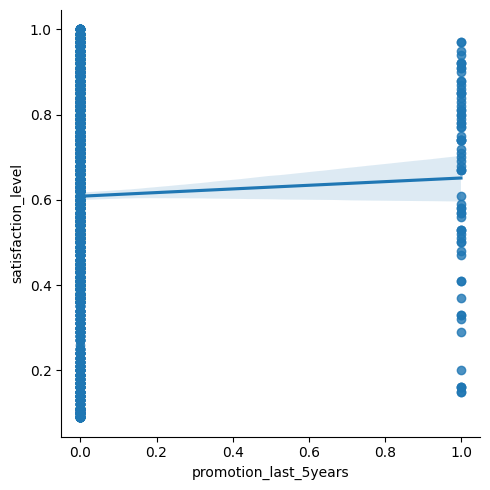

In [25]:
# regression plot, satisfaction vs if promoted in last 5 years
sns.lmplot(x='promotion_last_5years', y='satisfaction_level', data=df_sample)

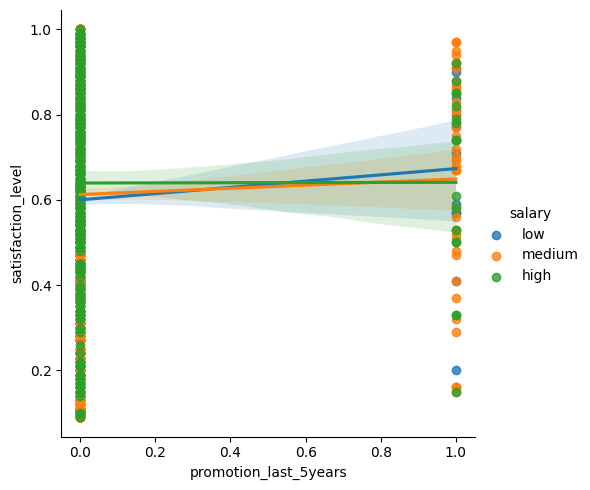

In [26]:
# regression plot, satisfaction vs if promoted in last 5 years, hue on salary
sns.lmplot(x='promotion_last_5years', y='satisfaction_level', data=df_sample, hue="salary")

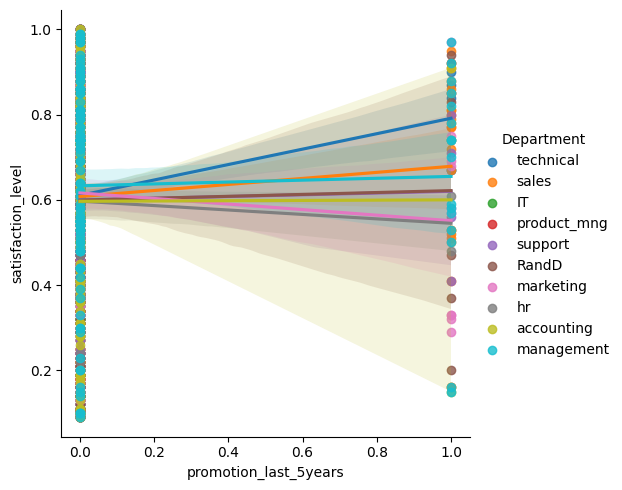

In [27]:
# regression plot, satisfaction vs if promoted in last 5 years, hue on department
sns.lmplot(x='promotion_last_5years', y='satisfaction_level', data=df_sample, hue="Department")

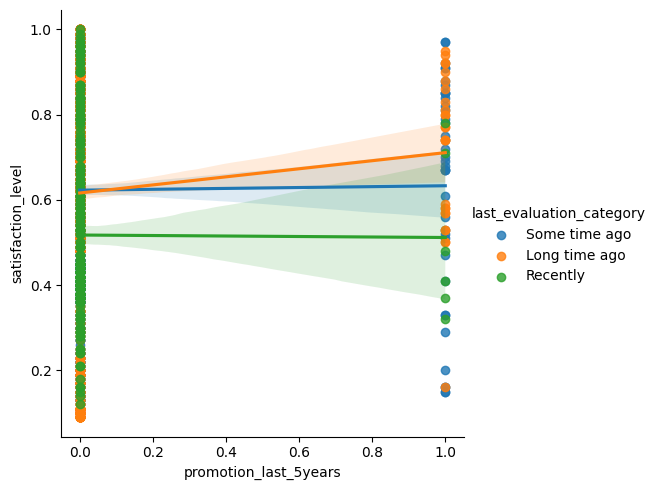

In [28]:
# regression plot, satisfaction vs if promoted in last 5 years, hue on last evaluation category
sns.lmplot(x='promotion_last_5years', y='satisfaction_level', data=df_sample, hue="last_evaluation_category")

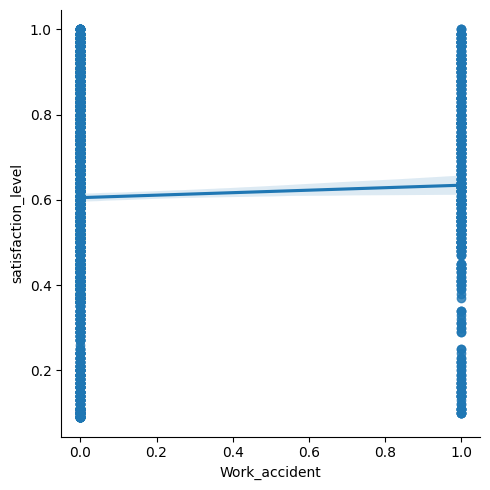

In [29]:
# regression plot, satisfaction vs if had work accident
sns.lmplot(x='Work_accident', y='satisfaction_level', data=df_sample)

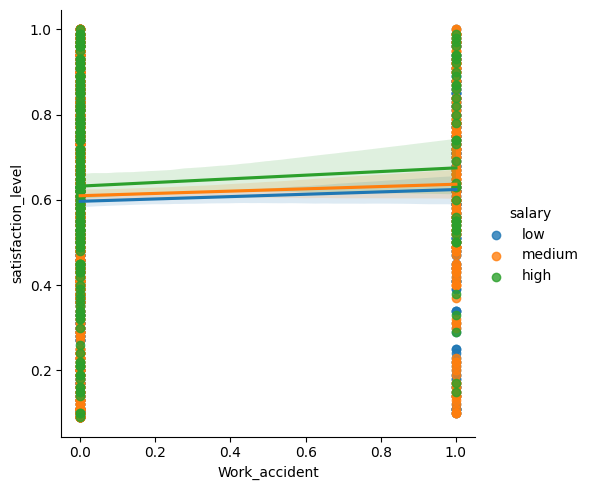

In [30]:
# regression plot, satisfaction vs if had work accident, hue on salary
sns.lmplot(x='Work_accident', y='satisfaction_level', data=df_sample, hue="salary")

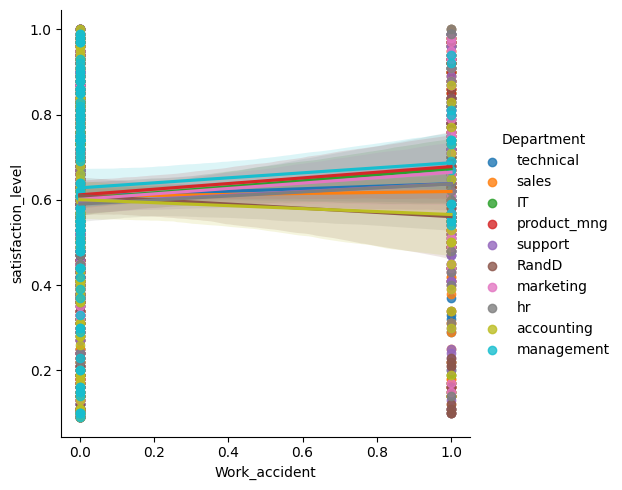

In [31]:
# regression plot, satisfaction vs if had work accident, hue on department
sns.lmplot(x='Work_accident', y='satisfaction_level', data=df_sample, hue="Department")

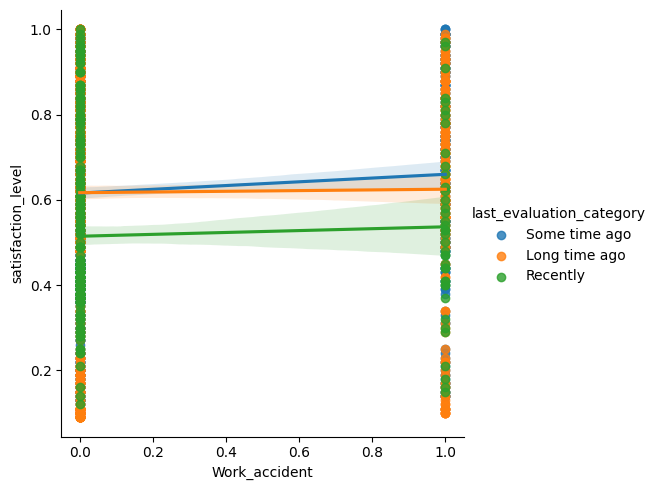

In [32]:
# regression plot, satisfaction vs if had work accident, hue on last evaluation category
sns.lmplot(x='Work_accident', y='satisfaction_level', data=df_sample, hue="last_evaluation_category")

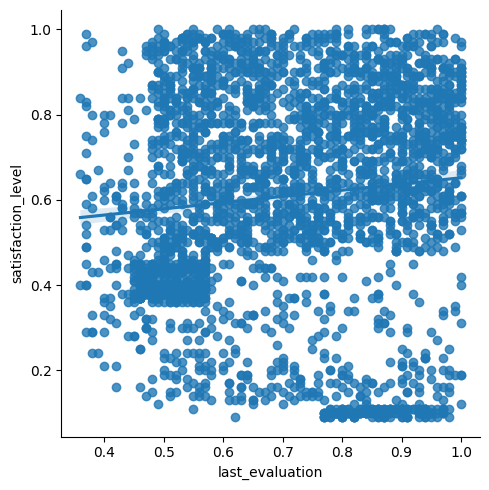

In [33]:
# regression plot, satisfaction vs last evaluation
sns.lmplot(x='last_evaluation', y='satisfaction_level', data=df_sample)

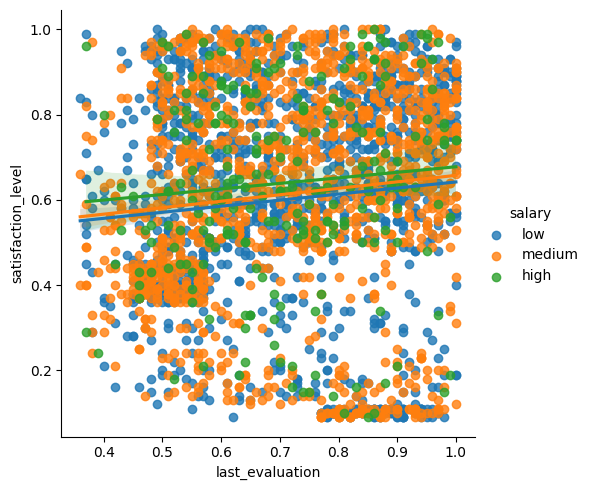

In [34]:
# regression plot, satisfaction vs last evaluation, hue on salary
sns.lmplot(x='last_evaluation', y='satisfaction_level', data=df_sample, hue='salary')

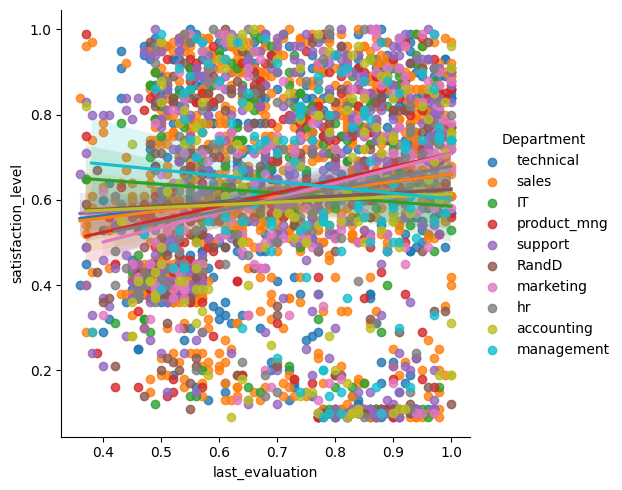

In [35]:
# regression plot, satisfaction vs last evaluation, hue on department
sns.lmplot(x='last_evaluation', y='satisfaction_level', data=df_sample, hue='Department')

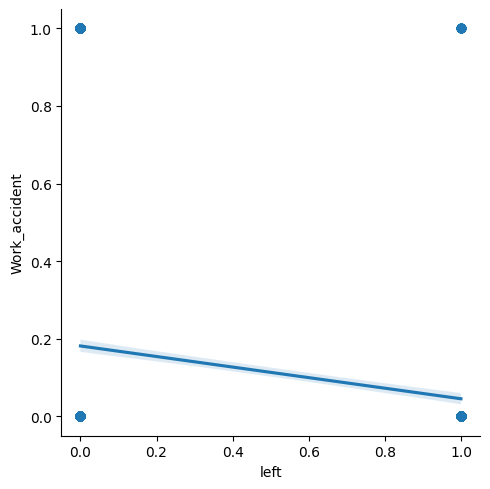

In [36]:
# regression plot, work accident vs if left company
sns.lmplot(x='left', y='Work_accident', data=df_sample)

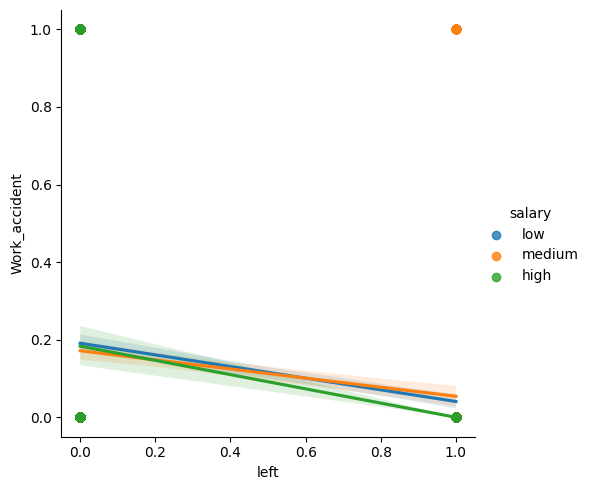

In [37]:
# regression plot, work accident vs if left company, hue on salary
sns.lmplot(x='left', y='Work_accident', data=df_sample, hue='salary')

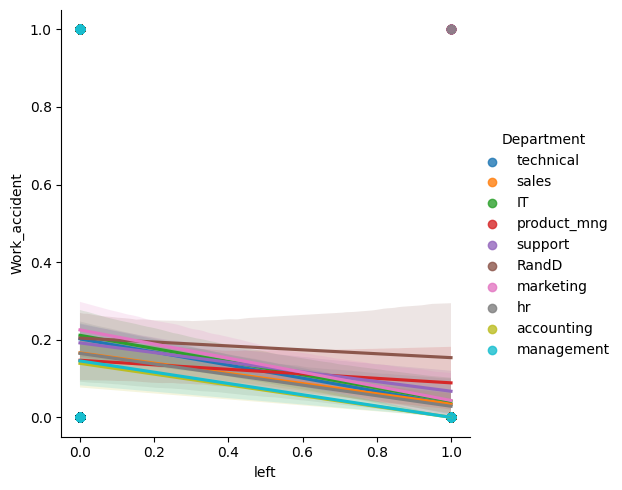

In [38]:
# regression plot, work accident vs if left company, hue on department
sns.lmplot(x='left', y='Work_accident', data=df_sample, hue='Department')

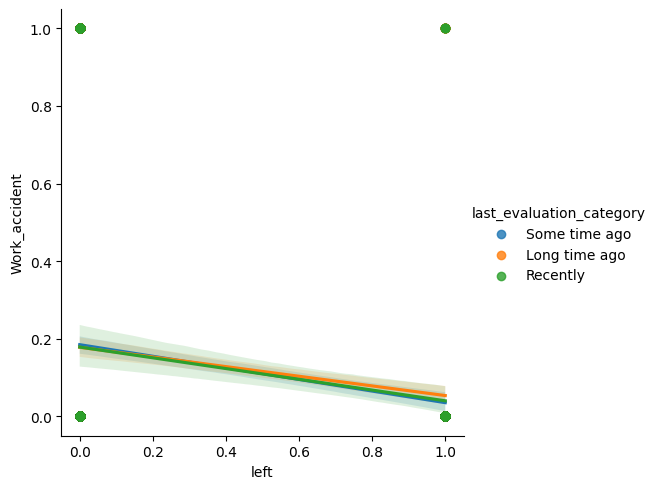

In [39]:
# regression plot, work accident vs if left company, hue on last evaluation category
sns.lmplot(x='left', y='Work_accident', data=df_sample, hue='last_evaluation_category')

<h4><b>seaborn plots - box plots</b></h4>

<Axes: xlabel='promotion_last_5years', ylabel='satisfaction_level'>

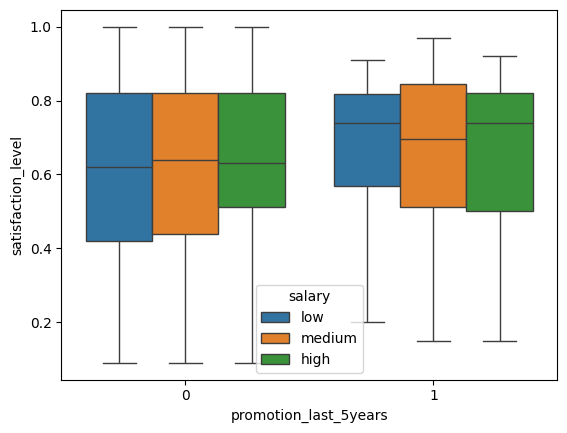

In [40]:
# box plot, promoted vs satisfaction, hue on department
sns.boxplot(x='promotion_last_5years', y='satisfaction_level', data=df_sample, hue='salary')

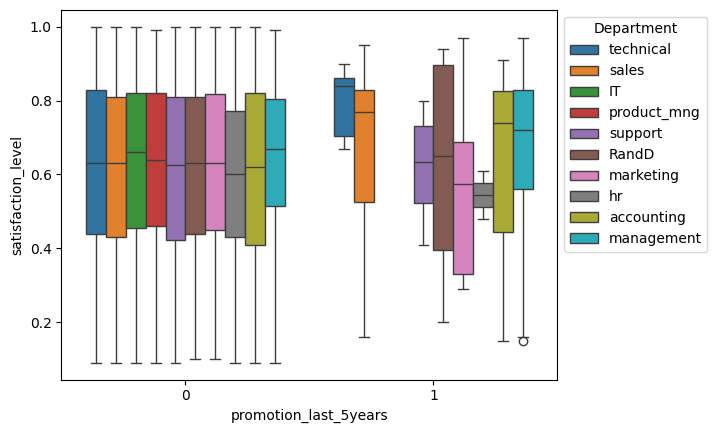

In [41]:
# box plot, promoted vs satisfaction, hue on department, also move the legend outside the chart to improve visibility
ax = sns.boxplot(x='promotion_last_5years', y='satisfaction_level', data=df_sample, hue='Department')
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))

<Axes: xlabel='promotion_last_5years', ylabel='satisfaction_level'>

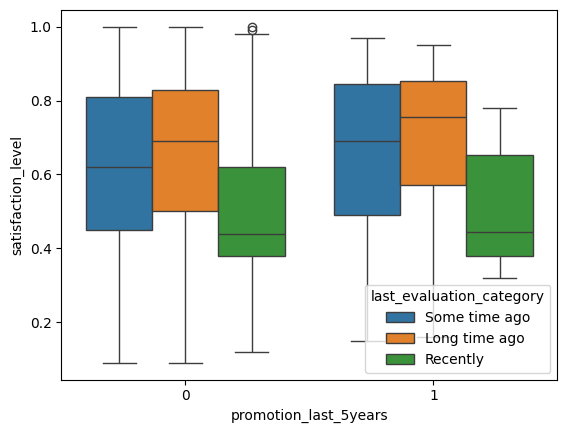

In [42]:
# box plot, promoted vs satisfaction, hue on department
sns.boxplot(x='promotion_last_5years', y='satisfaction_level', data=df_sample, hue='last_evaluation_category')

<Axes: xlabel='promotion_last_5years', ylabel='satisfaction_level'>

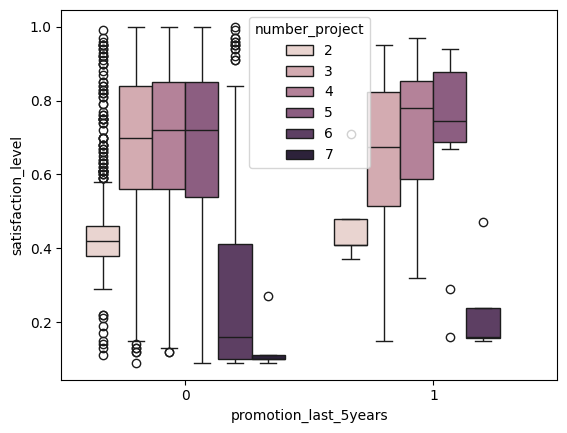

In [43]:
# box plot, promoted vs satisfaction, hue on department
sns.boxplot(x='promotion_last_5years', y='satisfaction_level', data=df_sample, hue='number_project')

In [44]:
# let's see the distribution in average hours
df_sample['average_montly_hours'].value_counts()

average_montly_hours
156    33
145    32
135    32
155    32
149    30
       ..
299     1
96      1
119     1
293     1
303     1
Name: count, Length: 214, dtype: int64

In [45]:
# let's see the distribution time spent while traveling to work
df_sample['time_spend_company'].value_counts()

time_spend_company
3     1278
2      653
4      509
5      302
6      138
10      46
7       37
8       37
Name: count, dtype: int64

In [46]:
# some more grouping with functions to use average montly hours and time spend company with box plot
def create_avg_hour_categories(row):
    hours = row['average_montly_hours']

    if 1 <= hours < 60:
        return 1
    elif 60 <= hours < 105:
        return 2
    elif 105 <= hours:
        return 3

# some more grouping with functions to use average montly hours and time spend company with box plot
def create_avg_travel_time(row):
    time = row['time_spend_company']

    if time <= 3:
        return 1
    elif 3 < time <= 5:
        return 2
    else:
        return 3

# create the new fields with the functions
df_sample['avg_hour_category'] = df_sample.apply(create_avg_hour_categories, axis=1)
df_sample['travel_category'] = df_sample.apply(create_avg_travel_time, axis=1)

<Axes: xlabel='avg_hour_category', ylabel='satisfaction_level'>

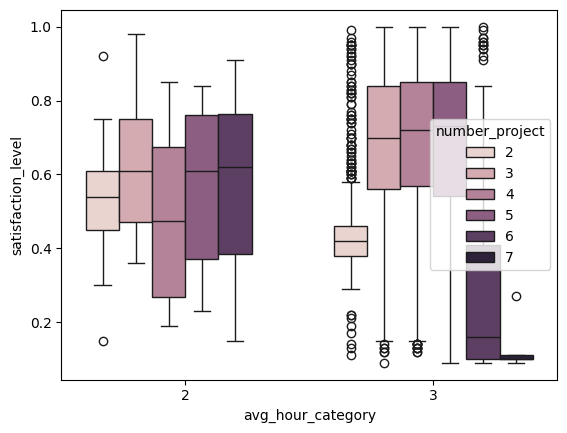

In [47]:
# box plot, promoted vs satisfaction, hue on department
sns.boxplot(x='avg_hour_category', y='satisfaction_level', data=df_sample, hue='number_project')

<Axes: xlabel='travel_category', ylabel='satisfaction_level'>

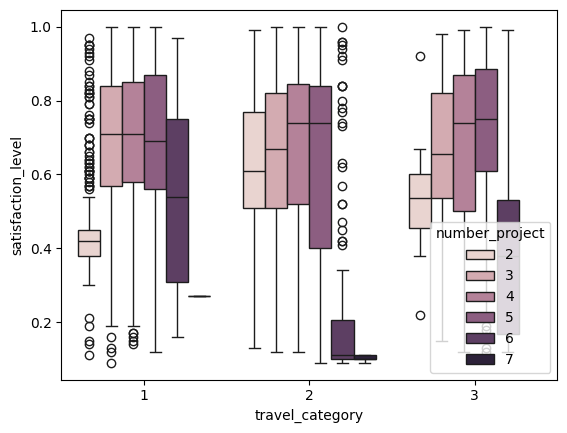

In [48]:
# box plot, promoted vs satisfaction, hue on department
sns.boxplot(x='travel_category', y='satisfaction_level', data=df_sample, hue='number_project')

<h4><b>seaborn plots - heatmaps for correlation matrices</b></h4>

<Axes: >

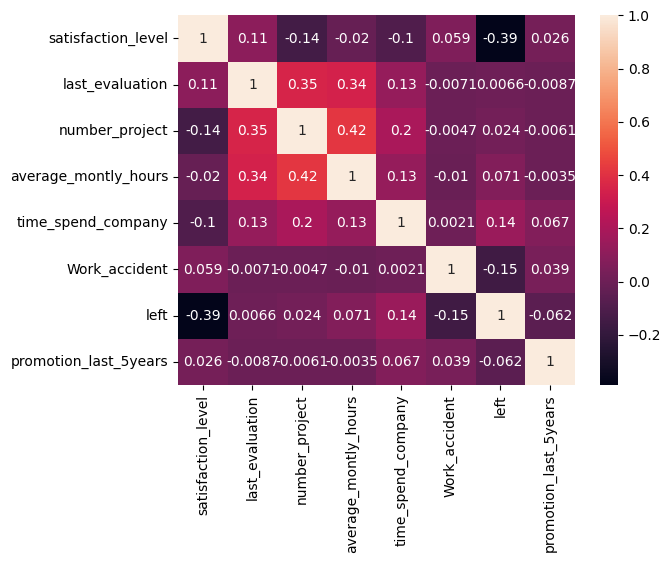

In [49]:
# basic heatmap for correlations
sns.heatmap(correlations, annot=True)